In [2]:
import skimage as ski
import numpy as np
import matplotlib.pyplot as plt

bild = ski.io.imread("ambassadors.jpg")
gletscher   = ski.io.imread("gletscher.jpg")
ambassadors = bild


In [ ]:
def bilinear_interpolate(img, x, y):
    """Bilineare Interpolation an Stelle (x, y) im Bild."""
    H, W = img.shape[:2]
    x0, y0 = int(np.floor(x)), int(np.floor(y))
    x1, y1 = x0 + 1, y0 + 1

    # Außerhalb des Bilds → 0
    if not (0 <= x0 < W and 0 <= x1 < W and 0 <= y0 < H and 0 <= y1 < H):
        return np.zeros(img.shape[2:], dtype=img.dtype) if img.ndim == 3 else img.dtype.type(0)

    # Flächenanteile (diagonal gegenüberliegend, wie im Skript)
    # P1=img[y0,x0] → Gewicht A1 = (x1-x)*(y1-y)  (diagonal gegenüber A4)
    A1 = (x1 - x) * (y1 - y)   
    A2 = (x  - x0) * (y1 - y) 
    A3 = (x1 - x) * (y  - y0)  
    A4 = (x  - x0) * (y  - y0) 

    p = (A1 * img[y0, x0].astype(float) +
         A2 * img[y0, x1].astype(float) +
         A3 * img[y1, x0].astype(float) +
         A4 * img[y1, x1].astype(float))

    return np.clip(p, 0, 255).astype(img.dtype)


In [ ]:
def affine_transform(A, a0, input_image, interpolation='nearest'):
    H, W = input_image.shape[:2]
    output = np.zeros_like(input_image)
    A_inv = np.linalg.inv(A)

    # Alle Ziel-Koordinaten auf einmal erzeugen (vektorisiert)
    y_img, x_img = np.mgrid[0:H, 0:W]  # je Shape (H, W)

    # Schritt 1: Linkshändig → Rechtshändig
    x_math = x_img.astype(float)
    y_math = (H - 1 - y_img).astype(float)

    coords_prime = np.stack([x_math.ravel(), y_math.ravel()])  # (2, H*W)

    # Schritt 2: Inverse affine Transformation
    coords_src = A_inv @ (coords_prime - a0[:, np.newaxis])    # (2, H*W)

    # Schritt 3: Rechtshändig → Linkshändig
    x_src = coords_src[0].reshape(H, W)
    y_src = (H - 1 - coords_src[1]).reshape(H, W)

    if interpolation == 'nearest':
        xi = np.round(x_src).astype(int)
        yi = np.round(y_src).astype(int)
        valid = (xi >= 0) & (xi < W) & (yi >= 0) & (yi < H)
        output[valid] = input_image[yi[valid], xi[valid]]

    elif interpolation == 'bilinear':
        for y in range(H):
            for x in range(W):
                output[y, x] = bilinear_interpolate(
                    input_image, x_src[y, x], y_src[y, x]
                )

    return output

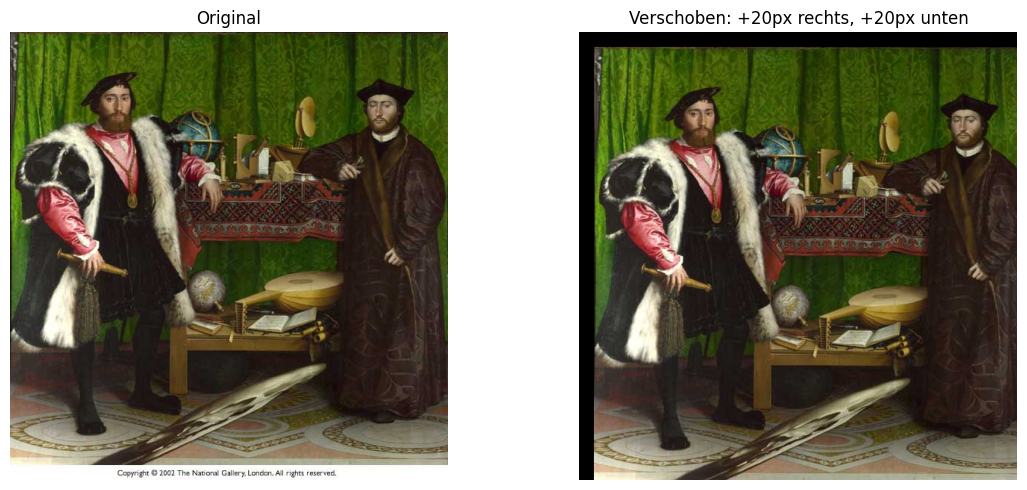

In [7]:
A_identity   = np.eye(2)
a0_translate = np.array([20.0, -20.0])  # rechtshändiges KS: rechts (+x), unten (-y)

result_translate = affine_transform(A_identity, a0_translate, bild)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(bild);             axes[0].set_title("Original")
axes[1].imshow(result_translate); axes[1].set_title("Verschoben: +20px rechts, +20px unten")
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

In [8]:
def affine_transform_sized(A, a0, input_image, out_shape, interpolation='nearest'):
    """Wie affine_transform, aber mit explizit vorgegebener Ausgabegröße."""
    H_out, W_out = out_shape[:2]
    H_in,  W_in  = input_image.shape[:2]
    output = np.zeros((H_out, W_out) + input_image.shape[2:], dtype=input_image.dtype)
    A_inv  = np.linalg.inv(A)

    y_img, x_img = np.mgrid[0:H_out, 0:W_out]

    # Schritt 1: Zielbild linkshändig → rechtshändig
    x_math = x_img.astype(float)
    y_math = (H_out - 1 - y_img).astype(float)

    coords_prime = np.stack([x_math.ravel(), y_math.ravel()])

    # Schritt 2: Inverse Transformation
    coords_src = A_inv @ (coords_prime - a0[:, np.newaxis])

    # Schritt 3: Quellbild rechtshändig → linkshändig (H_in!)
    x_src = coords_src[0].reshape(H_out, W_out)
    y_src = (H_in - 1 - coords_src[1]).reshape(H_out, W_out)

    if interpolation == 'nearest':
        xi = np.round(x_src).astype(int)
        yi = np.round(y_src).astype(int)
        valid = (xi >= 0) & (xi < W_in) & (yi >= 0) & (yi < H_in)
        output[valid] = input_image[yi[valid], xi[valid]]

    elif interpolation == 'bilinear':
        for y in range(H_out):
            for x in range(W_out):
                output[y, x] = bilinear_interpolate(
                    input_image, x_src[y, x], y_src[y, x]
                )
    return output

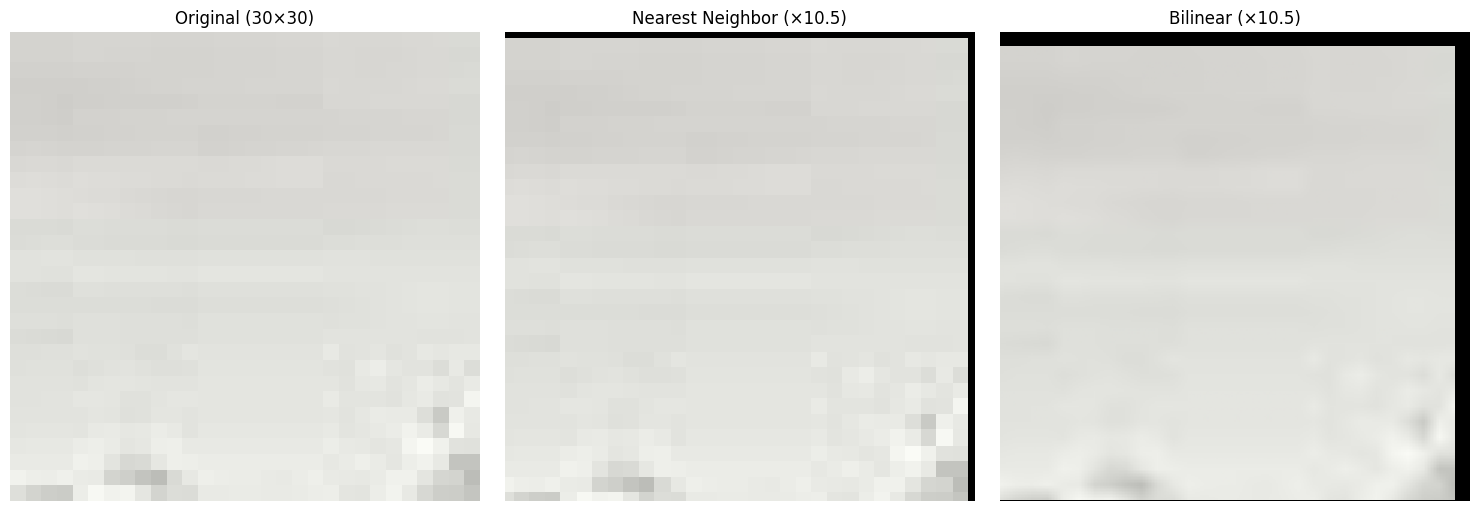

In [9]:
# 30×30 Ausschnitt aus gletscher.jpg
test_img = gletscher[100:130, 100:130]

factor = 10.5
H, W   = test_img.shape[:2]
H_out  = int(H * factor)
W_out  = int(W * factor)

A_zoom = np.array([[factor, 0.0], [0.0, factor]])
a0     = np.array([0.0, 0.0])

result_zoom_nn = affine_transform_sized(A_zoom, a0, test_img, (H_out, W_out), interpolation='nearest')
result_zoom_bl = affine_transform_sized(A_zoom, a0, test_img, (H_out, W_out), interpolation='bilinear')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(test_img,       interpolation='none'); axes[0].set_title("Original (30×30)")
axes[1].imshow(result_zoom_nn, interpolation='none'); axes[1].set_title(f"Nearest Neighbor (×{factor})")
axes[2].imshow(result_zoom_bl, interpolation='none'); axes[2].set_title(f"Bilinear (×{factor})")
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

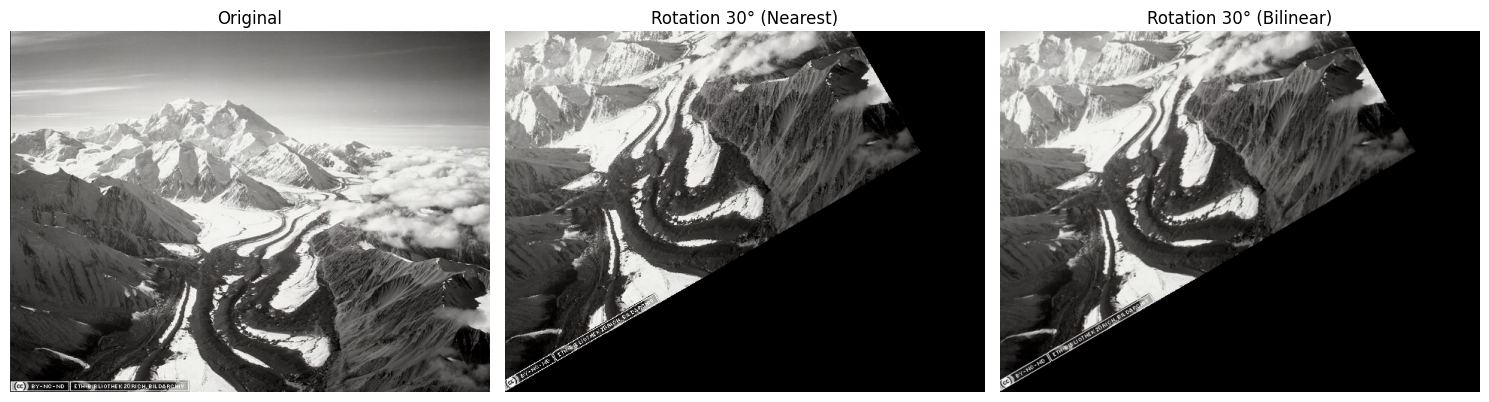

In [10]:
theta = np.radians(30)
A_rot = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])

result_rot_nn = affine_transform(A_rot, np.array([0.0, 0.0]), gletscher, interpolation='nearest')
result_rot_bl = affine_transform(A_rot, np.array([0.0, 0.0]), gletscher, interpolation='bilinear')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gletscher);      axes[0].set_title("Original")
axes[1].imshow(result_rot_nn);  axes[1].set_title("Rotation 30° (Nearest)")
axes[2].imshow(result_rot_bl);  axes[2].set_title("Rotation 30° (Bilinear)")
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

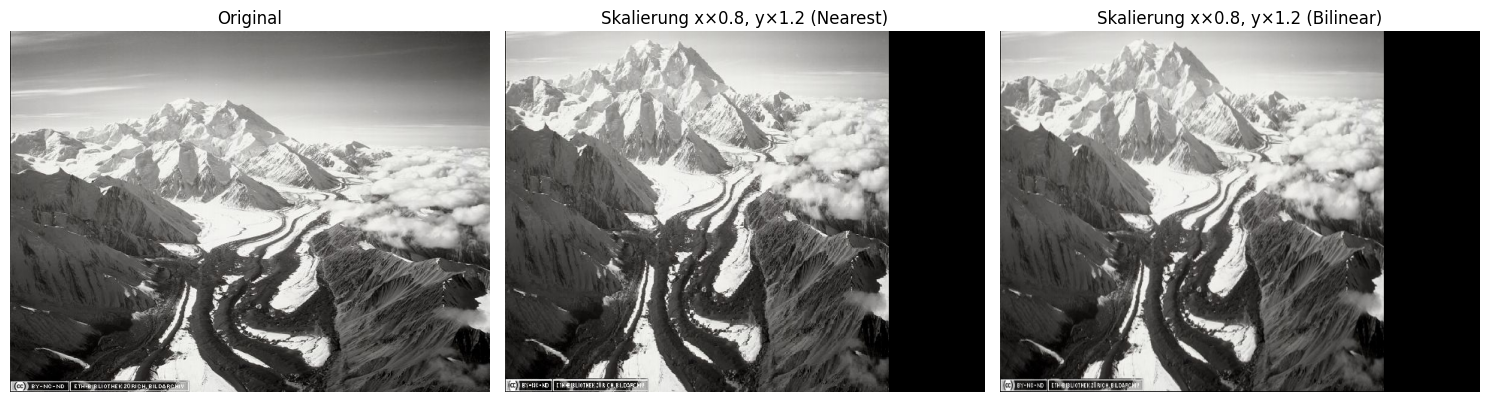

In [11]:
A_scale = np.array([[0.8, 0.0], [0.0, 1.2]])

result_scale_nn = affine_transform(A_scale, np.array([0.0, 0.0]), gletscher, interpolation='nearest')
result_scale_bl = affine_transform(A_scale, np.array([0.0, 0.0]), gletscher, interpolation='bilinear')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gletscher);        axes[0].set_title("Original")
axes[1].imshow(result_scale_nn);  axes[1].set_title("Skalierung x×0.8, y×1.2 (Nearest)")
axes[2].imshow(result_scale_bl);  axes[2].set_title("Skalierung x×0.8, y×1.2 (Bilinear)")
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

A_diag =
 [[1.  0.5]
 [0.5 1. ]]


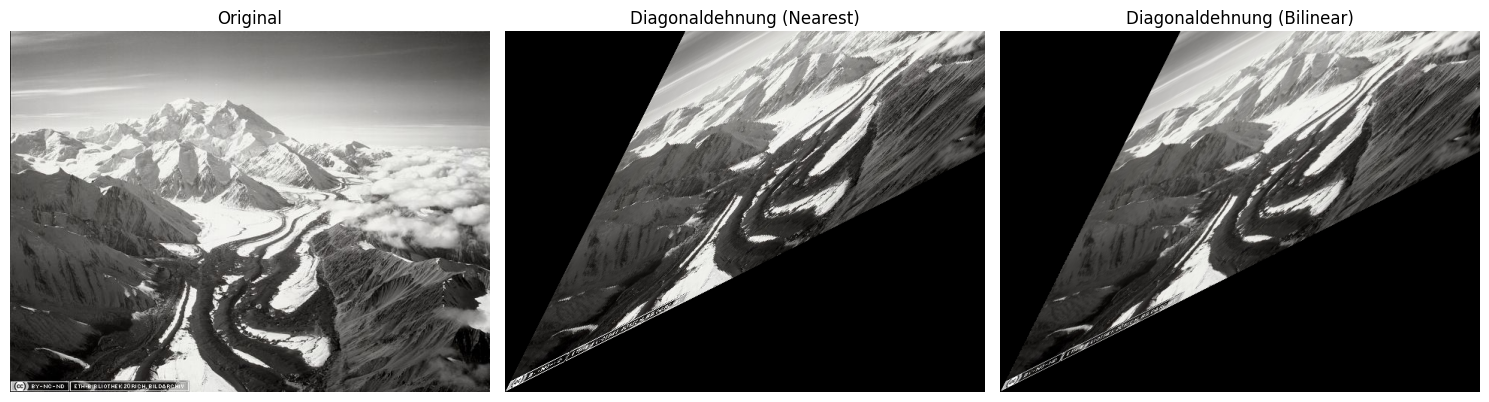

In [12]:
V      = np.array([[1/np.sqrt(2),  1/np.sqrt(2)],
                   [1/np.sqrt(2), -1/np.sqrt(2)]])
D      = np.diag([1.5, 0.5])
A_diag = V @ D @ V.T
print("A_diag =\n", np.round(A_diag, 4))

result_diag_nn = affine_transform(A_diag, np.array([0.0, 0.0]), gletscher, interpolation='nearest')
result_diag_bl = affine_transform(A_diag, np.array([0.0, 0.0]), gletscher, interpolation='bilinear')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gletscher);        axes[0].set_title("Original")
axes[1].imshow(result_diag_nn);   axes[1].set_title("Diagonaldehnung (Nearest)")
axes[2].imshow(result_diag_bl);   axes[2].set_title("Diagonaldehnung (Bilinear)")
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

In [38]:
def crop_black(image, threshold=10):
    """Schneidet schwarze Ränder weg (Pixel wo alle Kanäle < threshold)."""
    if image.ndim == 3:
        mask = np.any(image > threshold, axis=2)
    else:
        mask = image > threshold
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    if not rows.any() or not cols.any():
        return image
    r0, r1 = np.where(rows)[0][[0, -1]]
    c0, c1 = np.where(cols)[0][[0, -1]]
    return image[r0:r1+1, c0:c1+1]

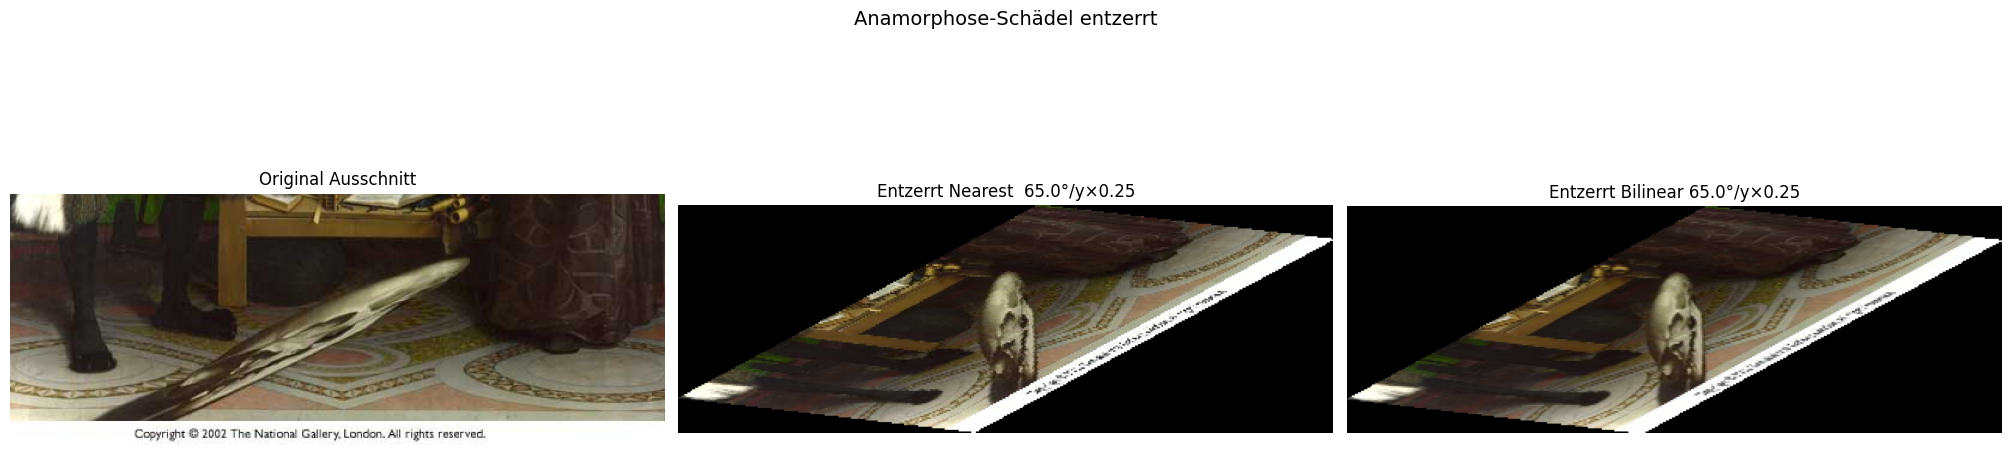

In [59]:
# Aufgabe d(4): Schädel entzerren – eine kombinierte affine Transformation
skull = ambassadors[390:630, 40:730]

best_angle = 65.0
best_sy    = 0.25

H, W  = skull.shape[:2]
center_in  = np.array([W / 2.0, H / 2.0])
H_out, W_out = 400, 860
center_out = np.array([W_out / 2.0, H_out / 2.0])

t       = np.radians(best_angle)
A_rot   = np.array([[np.cos(t), -np.sin(t)],
                    [np.sin(t),  np.cos(t)]])
A_scale = np.array([[1.0, 0.0],
                    [0.0, best_sy]])

# Eine kombinierte Matrix: erst drehen, dann Y stauchen
A_comb = A_scale @ A_rot
a0     = center_out - A_comb @ center_in

result_nn = affine_transform_sized(A_comb, a0, skull, (H_out, W_out), interpolation='nearest')
result_bl = affine_transform_sized(A_comb, a0, skull, (H_out, W_out), interpolation='bilinear')

cropped_nn = crop_black(result_nn)
cropped_bl = crop_black(result_bl)

fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
axes[0].imshow(skull);       axes[0].set_title("Original Ausschnitt")
axes[1].imshow(cropped_nn);  axes[1].set_title(f"Entzerrt Nearest  {best_angle}°/y×{best_sy}")
axes[2].imshow(cropped_bl);  axes[2].set_title(f"Entzerrt Bilinear {best_angle}°/y×{best_sy}")
for ax in axes:
    ax.axis('off')
plt.suptitle("Anamorphose-Schädel entzerrt", fontsize=14)
plt.show()